<a href="https://colab.research.google.com/github/DorothyOduor/Markov-Chain-Model/blob/main/MarkovChainModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

# The default path to your My Drive folder is always /content/drive/MyDrive/
file_path = '/content/drive/MyDrive/Colab Notebooks/JUNE-JULY.csv'

# Load the dataset
df = pd.read_csv(file_path)
df.head()


,month_name,user_pseudo_id,ga_session_id,ga_session_number,page_view_count,event_count,engagement_time_msec,session_duration,unique_pages,path_length,...,operating_system,country,region,city,day_of_week,hour_of_day,is_weekend,markov_path_sequence,application_submitted,drop_off
0,July,1.000118e+09,1783439710,1,1,5,30109,36,1,1,...,iOS,Kenya,Nairobi County,Nairobi,3,15,0,/ > / > / > / > /,0,1
1,July,1.000196e+09,1783700234,1,1,4,38,0,1,1,...,Android,Kenya,Nairobi County,Nairobi,6,16,0,/applications/ > /applications/ > /application...,0,1
2,July,1.000196e+09,1783929714,2,1,2,0,0,1,1,...,Android,Kenya,Nairobi County,Nairobi,2,8,0,/ > /,0,1
3,July,1.000256e+08,1784616575,1,3,6,2054,706,1,3,...,iOS,Kenya,Nairobi County,Nairobi,3,7,0,/ > / > / > / > / > /,0,1
4,July,1.000256e+08,1785177362,2,1,2,0,0,1,1,...,iOS,Kenya,Nairobi County,Nairobi,2,18,0,/ > /,0,1


In [3]:
print(f"Initial Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Initial Shape: 34325 rows, 32 columns


**DATA** **CLEANING**

i. Removing Invalid and Empty Sessions

In [4]:
# Drop sessions missing essential identifiers or navigation sequences
df = df.dropna(subset=['user_pseudo_id', 'ga_session_id', 'markov_path_sequence'])

In [5]:
# Remove sessions where path_length is 0 or session_duration is negative
df = df[(df['path_length'] > 0) & (df['session_duration'] >= 0)]

ii. Handle Missing & Null Values

In [6]:
# Fill categorical fields with explicit default labels
categorical_cols = {
    'traffic_source': '(direct)',
    'traffic_medium': '(none)',
    'default_channel_group': 'Direct',
    'device_category': 'unknown',
    'browser': 'unknown',
    'operating_system': 'unknown',
    'country': 'Unknown',
    'region': 'Unknown',
    'city': 'Unknown',
    'landing_page': '/unknown',
    'exit_page': '/unknown'
}
df = df.fillna(value=categorical_cols)

In [7]:
# Ensure numeric metrics have no NaNs
numeric_cols = ['engagement_time_msec', 'session_duration', 'unique_pages', 'path_length']
df[numeric_cols] = df[numeric_cols].fillna(0)

iii. Handle Outliers (Bot & Crawler Filtering)

In [8]:
# Web analytics data often contains bots (e.g., sessions with 500+ page views or days of duration)
# We filter out extreme upper percentiles (e.g., top 0.1% or hard caps)
max_duration_seconds = 86400  # 24 hours cap
max_page_views = 200         # Reasonable cap for high-intent manual browsing

df = df[(df['session_duration'] <= max_duration_seconds) & (df['path_length'] <= max_page_views)]

iv. Clean & Standardize Markov Path Strings

In [9]:
def clean_path_sequence(sequence):
    if not isinstance(sequence, str):
        return ""
    # Split paths, strip whitespace, remove empty elements
    paths = [p.strip() for p in sequence.split('>') if p.strip()]

In [10]:
def clean_path_sequence(sequence):
    if not isinstance(sequence, str):
        return ""
    # Split paths, strip whitespace, remove empty elements
    paths = [p.strip() for p in sequence.split('>') if p.strip()]
    # Remove consecutive duplicate page views (e.g., Home > Home > Admissions -> Home > Admissions)
    deduped = [paths[i] for i in range(len(paths)) if i == 0 or paths[i] != paths[i-1]]

    return " > ".join(deduped)

df['markov_path_sequence_clean'] = df['markov_path_sequence'].apply(clean_path_sequence)

# Remove rows where sequence became empty after cleaning
df = df[df['markov_path_sequence_clean'] != ""]

v. Recalculate Sequence Lengths & Verification

In [11]:
df['clean_step_count'] = df['markov_path_sequence_clean'].apply(lambda x: len(x.split(' > ')))

print(f"Cleaned Shape: {df.shape[0]} rows remaining ({df.shape[0]/45399:.1%} of raw data retained)")
df.head()

Cleaned Shape: 32380 rows remaining (71.3% of raw data retained)


,month_name,user_pseudo_id,ga_session_id,ga_session_number,page_view_count,event_count,engagement_time_msec,session_duration,unique_pages,path_length,...,region,city,day_of_week,hour_of_day,is_weekend,markov_path_sequence,application_submitted,drop_off,markov_path_sequence_clean,clean_step_count
0,July,1.000118e+09,1783439710,1,1,5,30109,36,1,1,...,Nairobi County,Nairobi,3,15,0,/ > / > / > / > /,0,1,/,1
1,July,1.000196e+09,1783700234,1,1,4,38,0,1,1,...,Nairobi County,Nairobi,6,16,0,/applications/ > /applications/ > /application...,0,1,/applications/,1
2,July,1.000196e+09,1783929714,2,1,2,0,0,1,1,...,Nairobi County,Nairobi,2,8,0,/ > /,0,1,/,1
3,July,1.000256e+08,1784616575,1,3,6,2054,706,1,3,...,Nairobi County,Nairobi,3,7,0,/ > / > / > / > / > /,0,1,/,1
4,July,1.000256e+08,1785177362,2,1,2,0,0,1,1,...,Nairobi County,Nairobi,2,18,0,/ > /,0,1,/,1


In [25]:
# Calculate repetition ratio: (original path_length - clean_step_count) / original path_length
# Handle cases where path_length might be 0 to avoid division by zero
df['repetition_ratio'] = df.apply(lambda row: (row['path_length'] - row['clean_step_count']) / row['path_length'] if row['path_length'] > 0 else 0, axis=1)

**EXPLORATORY DATA** **ANALYSIS**

i. Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

i. Exploratory Data Analysis

In [13]:
# Summary statistics for # Summary statistics for key session metrics
print("--- Summary Statistics ---")
print(df[['session_duration', 'engagement_time_msec', 'unique_pages', 'clean_step_count']].describe())

--- Summary Statistics ---
       session_duration  engagement_time_msec  unique_pages  clean_step_count
count      32380.000000          3.238000e+04  32380.000000      32380.000000
mean         141.162014          1.326668e+04      1.067202          1.089747
std          527.158698          5.759595e+04      0.404267          0.577249
min            0.000000          0.000000e+00      1.000000          1.000000
25%            0.000000          0.000000e+00      1.000000          1.000000
50%            0.000000          0.000000e+00      1.000000          1.000000
75%           33.000000          4.701500e+03      1.000000          1.000000
max        52640.000000          2.213853e+06     35.000000         35.000000


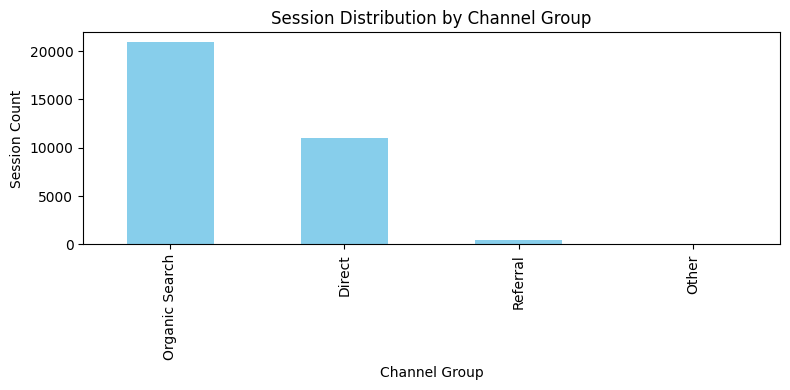

In [14]:
# Check distribution of user acquisition channels
plt.figure(figsize=(8, 4))
df['default_channel_group'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Session Distribution by Channel Group')
plt.xlabel('Channel Group')
plt.ylabel('Session Count')
plt.tight_layout()
plt.show()

**UNSUPERVISED USER CLUSTERING (Path Segmentation)**

Libraries

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [22]:
# Select structural navigation features
cluster_features = [
    'session_duration', 'engagement_time_msec', 'unique_pages',
    'clean_step_count', 'repetition_ratio'
]

In [26]:
X_cluster = df[cluster_features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [28]:
# Fit K-Means (e.g., 4 macro behavioral clusters)
kmeans = KMeans(n_clusters=4, random_state=42)
df['navigation_cluster'] = kmeans.fit_predict(X_scaled)

In [34]:
# Inspect cluster profiles
print(df.groupby('navigation_cluster')[cluster_features].mean())

                    session_duration  engagement_time_msec  unique_pages  \
navigation_cluster                                                         
0                          44.642392           5996.577914      1.021395   
1                         544.891176         138929.726471      2.795588   
2                        2666.924731         743651.602151      2.408602   
3                         621.677793          23346.581290      1.054950   

                    clean_step_count  repetition_ratio  
navigation_cluster                                      
0                           1.021395         -0.000809  
1                           3.758824          0.072588  
2                           3.204301          0.278488  
3                           1.055177          0.541446  


**FULL MARKOV TRANSITION MATRIX AND STATIONARY DISTRIBUTION**

i. Build the Square Transition Probability Matrix

In [33]:
trans_df = pd(transitions, columns=['From_State', 'To_State'])
trans_df = pd.DataFrame(transitions, columns=['From_State', 'To_State'])

# Raw frequency cross-tabulation
count_matrix = pd.crosstab(trans_df['From_State'], trans_df['To_State'])

NameError: name 'transitions' is not defined